# Chapter 12: Variations of Surfaces

Source orientation: printed pages 161-179; PDF pages 164-182. This notebook is original standalone course material. It uses the source only to orient the order of definitions, theorem statements, and examples; the prose, diagrams, computations, and checks here are authored for this course.


## Chapter Goal

Chapter 12 answers a variational question: when a surface moves through a one-parameter family, which part of the velocity changes the shape, which part only relabels the surface, and what local quantity is the gradient of area?

The computational goal is to make the formulas inspectable. We will compute surface `grad`, `div`, and `J`; decompose a variation field as

\[
\dot f = \phi N + df(Z);
\]

measure the local identity

\[
\dot{\det} = (2\phi H + \operatorname{div} Z)\det;
\]

and then connect the first variation formulas to minimal surfaces (`H=0`) and fixed-volume critical surfaces (`H` constant).


## Computational Translation Guide

A surface is represented by sampled coordinates `F(u,v)` together with the data derived from those samples: tangent vectors, metric coefficients, unit normal, area density, mean curvature, and divergence. The source uses the sign convention `dN=df(A)`, so a round sphere with outward normal has positive mean curvature `H=1/R`. The graph computations below use that convention.

A normal variation `phi N` is treated as shape-changing data. A tangential variation `df(Z)` is treated as a reparametrization in the interior; its contribution to total area becomes visible only at the boundary through a flux term. Finite differences measure the actual derivative of area, while the formulas compute the predicted derivative from `H`, `div Z`, and boundary flux.


## Visual Storyboard

| Storyboard item | Representation | Artifact | Check |
| --- | --- | --- | --- |
| Surface vector calculus | graph patch with intrinsic gradient, rotated-gradient divergence, and boundary flux | `surface-vector-calculus-dashboard.png` | `div(J grad g)`, product rule, divergence theorem |
| Variation field decomposition | 3D arrows for `phi N`, `df(Z)`, and their sum | `variation-field-decomposition.png` | normal/tangent reconstruction residuals |
| First area variation | finite-difference bars versus `2∫phi H det` and boundary flux | `first-area-variation-diagnostics.png` | normal and tangential derivative residuals |
| One-parameter deformation | Plotly slider for the normal bump family | `normal-variation-area-lab.html` | area samples saved and artifact exists |
| Minimal and CMC intuition | sphere/minimal/non-CMC comparison plus cone-volume check | `mean-curvature-volume-constraint.png` | sphere, Enneper, cone-volume, and multiplier identities |



## Route Through the Chapter

The notebook follows the same mathematical pressure as the chapter. It starts with intrinsic vector calculus because the first variation formulas only make sense after `grad`, `div`, `J`, and the area form are tied to the induced metric rather than to the flat parameter square. The first dashboard therefore asks the reader to inspect three independent facts at once: the gradient is metric-dual to the differential of a function, the rotated gradient is divergence-free, and a divergence integral is controlled by boundary flux.

The middle section then introduces a one-parameter family through its velocity field. The decomposition `dot f = phi N + df(Z)` is not just notation: `phi` is the scalar that pushes the surface through its normals, while `Z` is a tangent vector field that changes labels in the interior. The area diagnostics are organized to make that distinction measurable. The normal bump has zero boundary support, so its derivative is predicted by `2 int phi H det`. The tangential field has a boundary component, so its finite-difference derivative is compared with the flux term that comes from the divergence theorem.

The final section turns the formulas into Euler-Lagrange intuition. The symbolic sphere check fixes the sign convention for `H` and for the curvature-variation formula. The Enneper check supplies an exact minimal-surface witness without reproducing the source figure. The cone-volume computation then shows why the fixed-volume constraint changes the area equation from `H=0` to `H=constant`: the area gradient is `2H N`, while the cone-volume gradient is `N`, so the Lagrange multiplier can be constant only when `H` is constant.


In [1]:
from __future__ import annotations

from pathlib import Path
import math
import sys

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import sympy as sp

BOOK_ROOT = Path.cwd()
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the DGE-CWS book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import ARTIFACT_ROOT, book_relative, display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.plotting import PALETTE, add_note, image_stats, style_axis

CHAPTER = {
    "label": "Chapter 12",
    "title": "Variations of Surfaces",
    "topic": "chapter-12",
    "printed_pages": "161-179",
    "pdf_pages": "164-182",
}
TOPIC = CHAPTER["topic"]
ARTIFACT_DIR = ARTIFACT_ROOT / TOPIC
for subdir in ["figures", "interactive", "checks"]:
    (ARTIFACT_DIR / subdir).mkdir(parents=True, exist_ok=True)

STORYBOARD = {
    "chapter_goal": "Make variation fields, area variation, curvature variation, boundary terms, and fixed-volume CMC criticality computationally inspectable.",
    "source_printed_pages": CHAPTER["printed_pages"],
    "source_pdf_pages": CHAPTER["pdf_pages"],
    "visuals": [
        "surface vector-calculus dashboard",
        "variation field decomposition",
        "first area variation diagnostics",
        "normal variation area lab",
        "mean-curvature and cone-volume CMC comparison",
    ],
    "checks": [
        "div(J grad g) and product-rule residuals",
        "variation decomposition reconstruction residual",
        "normal and tangential first-area-variation residuals",
        "sphere curvature-variation and Enneper H=0 symbolic checks",
        "closed-sphere cone-volume translation residual and CMC multiplier check",
    ],
    "library_routing": {
        "NumPy": "finite-difference metric, divergence, area, and cone-volume checks on sampled surfaces",
        "Matplotlib": "durable labeled diagnostic panels and 3D arrow decomposition",
        "Plotly": "standalone interactive 3D one-parameter normal deformation",
        "SymPy": "exact sphere and Enneper identities that calibrate the source sign convention",
    },
}
storyboard_path = save_json(STORYBOARD, TOPIC, "checks", "visual-storyboard.json")
print(f"Book root: {BOOK_ROOT}")
print(f"Artifacts: {ARTIFACT_DIR.relative_to(BOOK_ROOT)}")
display_artifact(storyboard_path)


Book root: D:\Geometry\Differential-Geometry-From-Elastic-Curves-to-Willmore-Surfaces
Artifacts: artifacts\chapter-12


In [2]:
def trapz2(values: np.ndarray, u: np.ndarray, v: np.ndarray) -> float:
    # Integrate values on a tensor-product parameter grid.
    return float(np.trapezoid(np.trapezoid(values, u, axis=1), v, axis=0))


def derivatives(values: np.ndarray, u: np.ndarray, v: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    dv_values, du_values = np.gradient(values, v, u, edge_order=2)
    return du_values, dv_values


def height_function(U: np.ndarray, V: np.ndarray) -> np.ndarray:
    return (
        0.23 * np.exp(-1.7 * (U**2 + 0.65 * V**2))
        + 0.09 * np.sin(np.pi * U) * np.cos(0.5 * np.pi * V)
        + 0.06 * U * V
    )


def graph_data(u: np.ndarray, v: np.ndarray) -> dict[str, np.ndarray]:
    U, V = np.meshgrid(u, v)
    Z = height_function(U, V)
    Zu, Zv = derivatives(Z, u, v)
    Zuu, Zuv = derivatives(Zu, u, v)
    Zvu, Zvv = derivatives(Zv, u, v)
    W = np.sqrt(1.0 + Zu**2 + Zv**2)
    F = np.stack([U, V, Z], axis=-1)
    Fu = np.zeros_like(F)
    Fv = np.zeros_like(F)
    Fu[..., 0] = 1.0
    Fu[..., 2] = Zu
    Fv[..., 1] = 1.0
    Fv[..., 2] = Zv
    N = np.stack([-Zu / W, -Zv / W, 1.0 / W], axis=-1)
    E = 1.0 + Zu**2
    Fcoef = Zu * Zv
    G = 1.0 + Zv**2
    det_metric = W**2
    numerator = (1.0 + Zv**2) * Zuu - 2.0 * Zu * Zv * Zuv + (1.0 + Zu**2) * Zvv
    H = -numerator / (2.0 * W**3)
    K = (Zuu * Zvv - Zuv**2) / (W**4)
    return {
        "U": U,
        "V": V,
        "Z": Z,
        "Zu": Zu,
        "Zv": Zv,
        "F": F,
        "Fu": Fu,
        "Fv": Fv,
        "N": N,
        "W": W,
        "E": E,
        "Fcoef": Fcoef,
        "G": G,
        "det_metric": det_metric,
        "H": H,
        "K": K,
    }


def intrinsic_grad(q: np.ndarray, data: dict[str, np.ndarray], u: np.ndarray, v: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    qu, qv = derivatives(q, u, v)
    E = data["E"]
    Fcoef = data["Fcoef"]
    G = data["G"]
    det_metric = data["det_metric"]
    grad_u = (G * qu - Fcoef * qv) / det_metric
    grad_v = (-Fcoef * qu + E * qv) / det_metric
    return grad_u, grad_v


def surface_divergence(Yu: np.ndarray, Yv: np.ndarray, data: dict[str, np.ndarray], u: np.ndarray, v: np.ndarray) -> np.ndarray:
    W = data["W"]
    d_wyu_du, _ = derivatives(W * Yu, u, v)
    _, d_wyv_dv = derivatives(W * Yv, u, v)
    return (d_wyu_du + d_wyv_dv) / W


def rotate_J(Yu: np.ndarray, Yv: np.ndarray, data: dict[str, np.ndarray]) -> tuple[np.ndarray, np.ndarray]:
    E = data["E"]
    Fcoef = data["Fcoef"]
    G = data["G"]
    W = data["W"]
    return (-(Fcoef * Yu + G * Yv) / W, (E * Yu + Fcoef * Yv) / W)


def surface_area(surface: np.ndarray, u: np.ndarray, v: np.ndarray) -> float:
    dF_dv, dF_du = np.gradient(surface, v, u, axis=(0, 1), edge_order=2)
    density = np.linalg.norm(np.cross(dF_du, dF_dv), axis=-1)
    return trapz2(density, u, v)


def parameter_boundary_flux(W: np.ndarray, Zu: np.ndarray, Zv: np.ndarray, u: np.ndarray, v: np.ndarray) -> float:
    right = np.trapezoid(W[:, -1] * Zu[:, -1], v)
    left = np.trapezoid(W[:, 0] * Zu[:, 0], v)
    top = np.trapezoid(W[-1, :] * Zv[-1, :], u)
    bottom = np.trapezoid(W[0, :] * Zv[0, :], u)
    return float(right - left + top - bottom)


def vector_norm(values: np.ndarray) -> np.ndarray:
    return np.linalg.norm(values, axis=-1)


## Surface Vector Calculus on a Graph Patch

The first section of the chapter builds vector calculus from the induced metric. On a graph surface `f(u,v)=(u,v,h(u,v))`, the metric is explicit, so we can compute the metric-dual gradient, the divergence formula

\[
\operatorname{div}Y={1\over \sqrt{\det g}}\partial_i(\sqrt{\det g}\,Y^i),
\]

and the 90-degree rotation `J`. The dashboard below is a local test bench for three facts: `grad` is metric-aware, `div(J grad g)` vanishes, and the integral of a divergence equals the outward boundary flux.


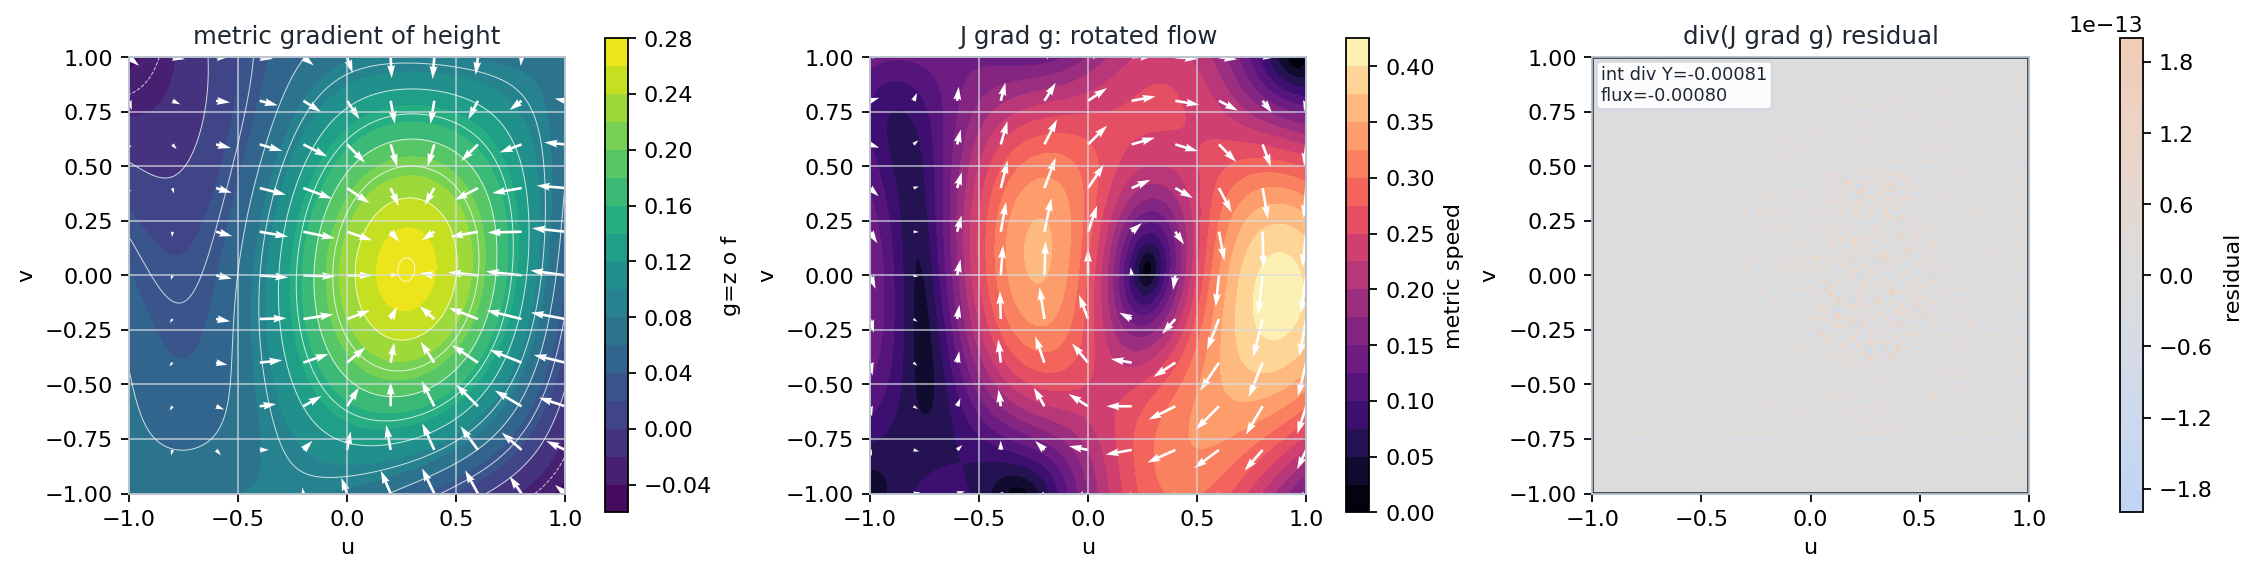

In [3]:
u = np.linspace(-1.0, 1.0, 151)
v = np.linspace(-1.0, 1.0, 151)
data = graph_data(u, v)
U, V, Z = data["U"], data["V"], data["Z"]
W = data["W"]

grad_u, grad_v = intrinsic_grad(Z, data, u, v)
Jgrad_u, Jgrad_v = rotate_J(grad_u, grad_v, data)
div_J_grad = surface_divergence(Jgrad_u, Jgrad_v, data, u, v)

Y_u = 0.16 * np.sin(np.pi * U) * (1.0 - 0.25 * V)
Y_v = -0.12 * np.cos(0.5 * np.pi * V) + 0.06 * U
q = 1.0 + 0.35 * Z
q_grad_u, q_grad_v = intrinsic_grad(q, data, u, v)
div_Y = surface_divergence(Y_u, Y_v, data, u, v)
div_qY = surface_divergence(q * Y_u, q * Y_v, data, u, v)
inner_grad_q_Y = data["E"] * q_grad_u * Y_u + data["Fcoef"] * (q_grad_u * Y_v + q_grad_v * Y_u) + data["G"] * q_grad_v * Y_v
product_residual = div_qY - (inner_grad_q_Y + q * div_Y)

int_div = trapz2(div_Y * W, u, v)
boundary_flux = parameter_boundary_flux(W, Y_u, Y_v, u, v)
interior = np.s_[4:-4, 4:-4]
vector_checks = {
    "div_J_grad_max_abs_interior": float(np.max(np.abs(div_J_grad[interior]))),
    "div_J_grad_rms_interior": float(np.sqrt(np.mean(div_J_grad[interior] ** 2))),
    "product_rule_max_abs_interior": float(np.max(np.abs(product_residual[interior]))),
    "divergence_integral": float(int_div),
    "boundary_flux": float(boundary_flux),
    "divergence_theorem_abs_error": float(abs(int_div - boundary_flux)),
    "area_density_min": float(W.min()),
}
assert vector_checks["div_J_grad_max_abs_interior"] < 1e-9
assert vector_checks["product_rule_max_abs_interior"] < 2e-3
assert vector_checks["divergence_theorem_abs_error"] < 3e-4

fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.2), constrained_layout=True)
c0 = axes[0].contourf(U, V, Z, levels=18, cmap="viridis")
axes[0].contour(U, V, Z, levels=10, colors="white", linewidths=0.45, alpha=0.75)
step = 15
axes[0].quiver(U[::step, ::step], V[::step, ::step], grad_u[::step, ::step], grad_v[::step, ::step], color="white", scale=4.5, width=0.006)
style_axis(axes[0], "metric gradient of height", equal=True)
axes[0].set_xlabel("u")
axes[0].set_ylabel("v")
fig.colorbar(c0, ax=axes[0], shrink=0.72, label="g=z o f")

speed = np.sqrt(data["E"] * Jgrad_u**2 + 2 * data["Fcoef"] * Jgrad_u * Jgrad_v + data["G"] * Jgrad_v**2)
c1 = axes[1].contourf(U, V, speed, levels=18, cmap="magma")
axes[1].quiver(U[::step, ::step], V[::step, ::step], Jgrad_u[::step, ::step], Jgrad_v[::step, ::step], color="white", scale=4.5, width=0.006)
style_axis(axes[1], "J grad g: rotated flow", equal=True)
axes[1].set_xlabel("u")
axes[1].set_ylabel("v")
fig.colorbar(c1, ax=axes[1], shrink=0.72, label="metric speed")

bound = np.percentile(np.abs(div_J_grad[interior]), 99.5)
bound = max(bound, 1e-12)
c2 = axes[2].contourf(U, V, div_J_grad, levels=21, cmap="coolwarm", vmin=-bound, vmax=bound)
axes[2].plot([u[0], u[-1], u[-1], u[0], u[0]], [v[0], v[0], v[-1], v[-1], v[0]], color=PALETTE["ink"], lw=1.6)
add_note(axes[2], f"int div Y={int_div:.5f}\nflux={boundary_flux:.5f}")
style_axis(axes[2], "div(J grad g) residual", equal=True)
axes[2].set_xlabel("u")
axes[2].set_ylabel("v")
fig.colorbar(c2, ax=axes[2], shrink=0.72, label="residual")

vector_path = save_matplotlib(fig, TOPIC, "figures", "surface-vector-calculus-dashboard.png")
plt.close(fig)
vector_checks_path = save_json(vector_checks, TOPIC, "checks", "surface-vector-calculus-checks.json")
display_artifact(vector_path)
display_artifact(vector_checks_path)


## Variation Fields: Normal Motion Plus Tangential Relabeling

For a surface in `R^3`, every variation vector field along the surface splits into a normal speed and a tangent field:

\[
\dot f = \phi N + df(Z).
\]

The split matters because the normal part changes the shape directly, while the tangential part mostly changes which parameter point names which surface point. The boundary is the exception: if `Z` pushes boundary points outward, area changes through a boundary flux.


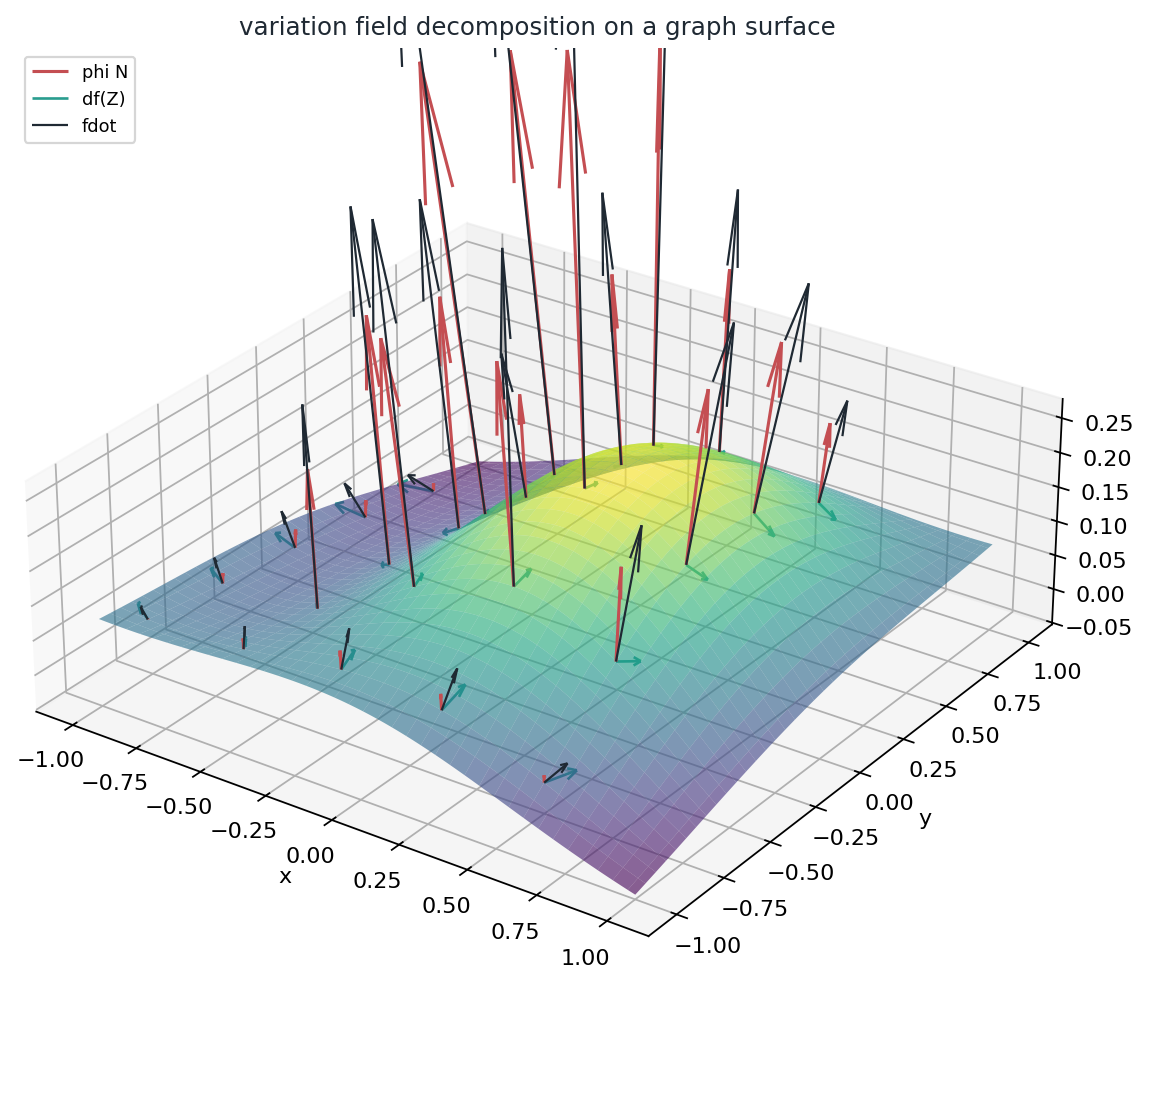

In [4]:
phi = (1.0 - U**2) ** 2 * (1.0 - V**2) ** 2
Z_u = 0.08 * U * (1.0 + 0.2 * np.sin(np.pi * V))
Z_v = -0.05 * V + 0.02 * np.cos(0.5 * np.pi * U)
normal_part = phi[..., None] * data["N"]
tangent_part = Z_u[..., None] * data["Fu"] + Z_v[..., None] * data["Fv"]
fdot = normal_part + tangent_part

normal_coeff = np.einsum("ijk,ijk->ij", fdot, data["N"])
tangent_dot_normal = np.einsum("ijk,ijk->ij", tangent_part, data["N"])
reconstructed = normal_coeff[..., None] * data["N"] + tangent_part
variation_checks = {
    "normal_coefficient_max_abs_error": float(np.max(np.abs(normal_coeff - phi))),
    "tangent_dot_normal_max_abs": float(np.max(np.abs(tangent_dot_normal))),
    "reconstruction_max_abs_error": float(np.max(np.abs(reconstructed - fdot))),
    "normal_speed_max": float(np.max(np.abs(phi))),
    "tangent_speed_max": float(np.max(vector_norm(tangent_part))),
}
assert variation_checks["normal_coefficient_max_abs_error"] < 1e-12
assert variation_checks["tangent_dot_normal_max_abs"] < 1e-12
assert variation_checks["reconstruction_max_abs_error"] < 1e-12

fig = plt.figure(figsize=(9.0, 6.8), constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(U, V, Z, cmap="viridis", alpha=0.62, linewidth=0, antialiased=True)
arrow_step = 28
S = np.s_[8:-8:arrow_step, 8:-8:arrow_step]
P = data["F"][S]
Npart = normal_part[S]
Tpart = tangent_part[S]
Total = fdot[S]
ax.quiver(P[..., 0], P[..., 1], P[..., 2], Npart[..., 0], Npart[..., 1], Npart[..., 2], length=0.7, normalize=False, color=PALETTE["red"], linewidth=1.4, label="phi N")
ax.quiver(P[..., 0], P[..., 1], P[..., 2], Tpart[..., 0], Tpart[..., 1], Tpart[..., 2], length=1.4, normalize=False, color=PALETTE["teal"], linewidth=1.2, label="df(Z)")
ax.quiver(P[..., 0], P[..., 1], P[..., 2], Total[..., 0], Total[..., 1], Total[..., 2], length=1.0, normalize=False, color=PALETTE["ink"], linewidth=1.0, label="fdot")
ax.set_title("variation field decomposition on a graph surface", fontsize=11, color=PALETTE["ink"])
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.view_init(elev=28, azim=-55)
ax.set_box_aspect((1, 1, 0.35))
ax.legend(loc="upper left", fontsize=8)
variation_path = save_matplotlib(fig, TOPIC, "figures", "variation-field-decomposition.png")
plt.close(fig)
variation_checks_path = save_json(variation_checks, TOPIC, "checks", "variation-decomposition-checks.json")
display_artifact(variation_path)
display_artifact(variation_checks_path)


## First Variation of Area

The local area-density formula is the hinge of the chapter:

\[
\dot{\det}=(2\phi H+\operatorname{div}Z)\det.
\]

Integrating gives the first variation of area. If `phi` is the only speed and it is supported away from the boundary, the derivative is `2∫phi H det`. If the variation is purely tangential, the interior term integrates to the boundary flux. The next computation measures both statements by central finite differences of the actual deformed surface area.


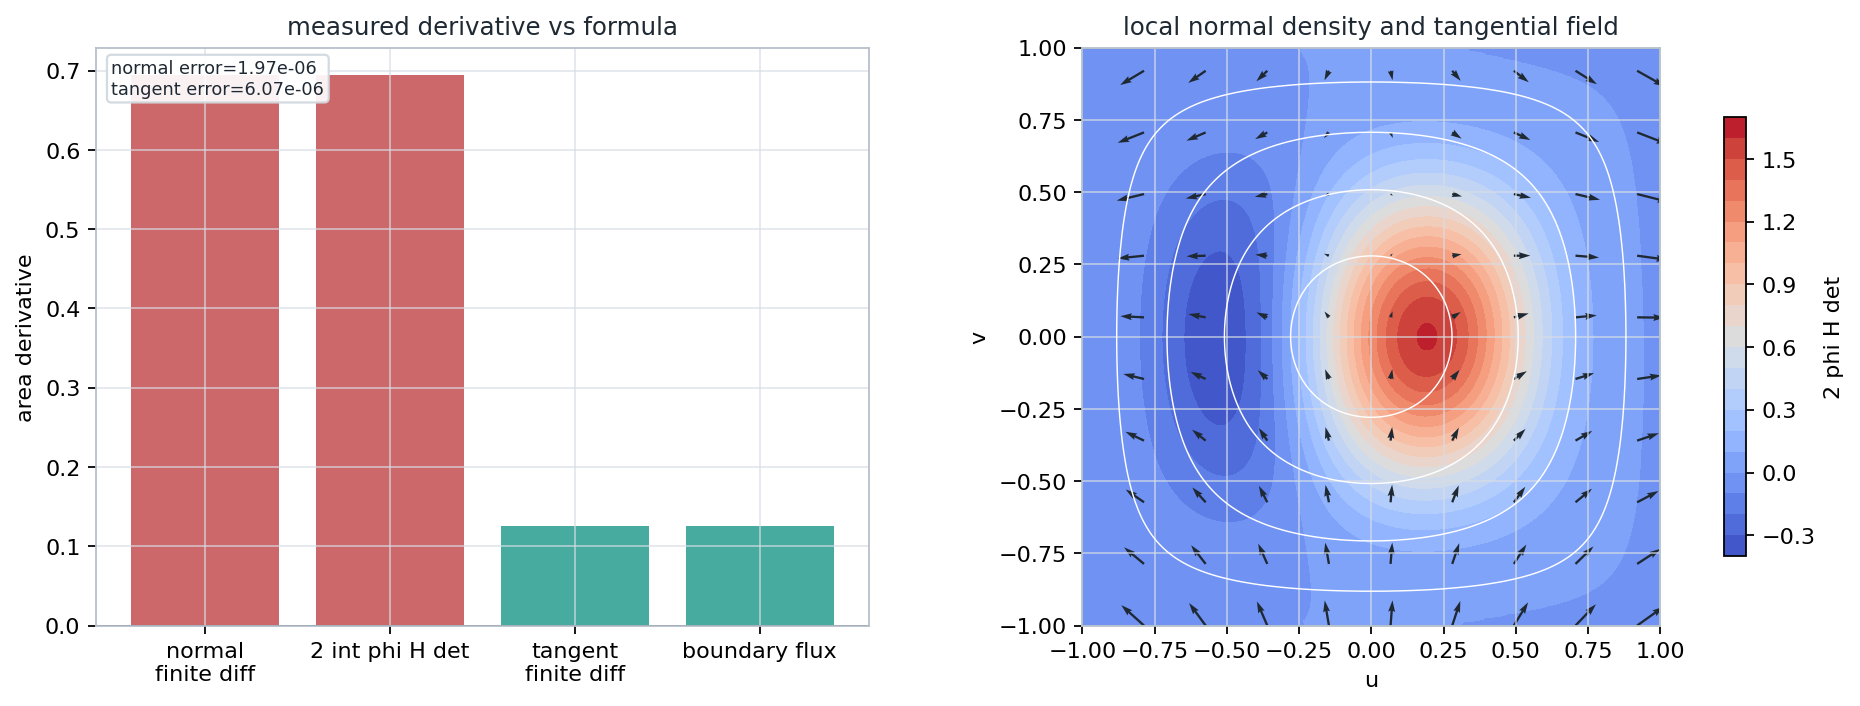

In [5]:
delta = 1e-4
F0 = data["F"]
H = data["H"]
N = data["N"]

area_base = surface_area(F0, u, v)
normal_velocity = phi[..., None] * N
normal_area_plus = surface_area(F0 + delta * normal_velocity, u, v)
normal_area_minus = surface_area(F0 - delta * normal_velocity, u, v)
normal_fd = (normal_area_plus - normal_area_minus) / (2.0 * delta)
normal_formula = 2.0 * trapz2(phi * H * W, u, v)

tangent_velocity = tangent_part
tangent_area_plus = surface_area(F0 + delta * tangent_velocity, u, v)
tangent_area_minus = surface_area(F0 - delta * tangent_velocity, u, v)
tangent_fd = (tangent_area_plus - tangent_area_minus) / (2.0 * delta)
tangent_divergence = surface_divergence(Z_u, Z_v, data, u, v)
tangent_div_integral = trapz2(tangent_divergence * W, u, v)
tangent_flux = parameter_boundary_flux(W, Z_u, Z_v, u, v)

area_checks = {
    "base_area": float(area_base),
    "normal_area_derivative_finite_difference": float(normal_fd),
    "normal_area_derivative_formula": float(normal_formula),
    "normal_area_abs_error": float(abs(normal_fd - normal_formula)),
    "tangential_area_derivative_finite_difference": float(tangent_fd),
    "tangential_divergence_integral": float(tangent_div_integral),
    "tangential_boundary_flux": float(tangent_flux),
    "tangential_area_abs_error": float(abs(tangent_fd - tangent_flux)),
    "tangential_div_flux_abs_error": float(abs(tangent_div_integral - tangent_flux)),
}
assert area_checks["normal_area_abs_error"] < 5e-5
assert area_checks["tangential_area_abs_error"] < 5e-5
assert area_checks["tangential_div_flux_abs_error"] < 5e-5

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), constrained_layout=True)
labels = ["normal\nfinite diff", "2 int phi H det", "tangent\nfinite diff", "boundary flux"]
values = [normal_fd, normal_formula, tangent_fd, tangent_flux]
colors = [PALETTE["red"], PALETTE["red"], PALETTE["teal"], PALETTE["teal"]]
axes[0].bar(labels, values, color=colors, alpha=0.86)
axes[0].axhline(0, color=PALETTE["ink"], lw=0.8)
axes[0].set_ylabel("area derivative")
add_note(axes[0], f"normal error={area_checks['normal_area_abs_error']:.2e}\ntangent error={area_checks['tangential_area_abs_error']:.2e}")
style_axis(axes[0], "measured derivative vs formula")

c = axes[1].contourf(U, V, 2.0 * phi * H * W, levels=21, cmap="coolwarm")
axes[1].contour(U, V, phi, levels=[0.05, 0.25, 0.55, 0.85], colors="white", linewidths=0.65)
axes[1].quiver(U[::16, ::16], V[::16, ::16], Z_u[::16, ::16], Z_v[::16, ::16], color=PALETTE["ink"], scale=1.6, width=0.004)
style_axis(axes[1], "local normal density and tangential field", equal=True)
axes[1].set_xlabel("u")
axes[1].set_ylabel("v")
fig.colorbar(c, ax=axes[1], shrink=0.76, label="2 phi H det")

area_path = save_matplotlib(fig, TOPIC, "figures", "first-area-variation-diagnostics.png")
plt.close(fig)
area_checks_path = save_json(area_checks, TOPIC, "checks", "area-variation-checks.json")
display_artifact(area_path)
display_artifact(area_checks_path)


In [6]:
ui = np.linspace(-1.0, 1.0, 61)
vi = np.linspace(-1.0, 1.0, 61)
idata = graph_data(ui, vi)
Ui, Vi = idata["U"], idata["V"]
phii = (1.0 - Ui**2) ** 2 * (1.0 - Vi**2) ** 2
normal_i = idata["N"]
F_i = idata["F"]
slider_times = [-0.35, -0.18, 0.0, 0.18, 0.35]
area_samples = []
frames = []
for time_value in slider_times:
    Ft = F_i + time_value * phii[..., None] * normal_i
    area_t = surface_area(Ft, ui, vi)
    area_samples.append({"t": float(time_value), "area": float(area_t)})
    frames.append(
        go.Frame(
            data=[go.Surface(x=Ft[..., 0], y=Ft[..., 1], z=Ft[..., 2], surfacecolor=phii, colorscale="Viridis", cmin=0, cmax=1, showscale=True)],
            name=f"t={time_value:.2f}",
            layout=go.Layout(title_text=f"normal variation f_t=f+t phi N, t={time_value:.2f}, area={area_t:.5f}"),
        )
    )
F_start = F_i + slider_times[0] * phii[..., None] * normal_i
fig3 = go.Figure(
    data=[go.Surface(x=F_start[..., 0], y=F_start[..., 1], z=F_start[..., 2], surfacecolor=phii, colorscale="Viridis", cmin=0, cmax=1, showscale=True)],
    frames=frames,
)
fig3.update_layout(
    title=f"normal variation f_t=f+t phi N, t={slider_times[0]:.2f}, area={area_samples[0]['area']:.5f}",
    height=560,
    scene={"aspectmode": "data", "xaxis_title": "x", "yaxis_title": "y", "zaxis_title": "z"},
    updatemenus=[{"type": "buttons", "showactive": False, "buttons": [{"label": "Play", "method": "animate", "args": [None, {"frame": {"duration": 850, "redraw": True}, "fromcurrent": True}]}]}],
    sliders=[{
        "steps": [{"label": f"{time_value:.2f}", "method": "animate", "args": [[f"t={time_value:.2f}"], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}]} for time_value in slider_times],
        "active": 0,
        "currentvalue": {"prefix": "t = "},
    }],
)
interactive_path = save_plotly_html(fig3, TOPIC, "interactive", "normal-variation-area-lab.html")
interactive_checks = save_json({"area_samples": area_samples}, TOPIC, "checks", "normal-variation-area-samples.json")
display_artifact(interactive_path, height=460)
display_artifact(interactive_checks)


## Curvature Variation: Calibrating the Sign Convention

The curvature-variation formula contains a tangential transport term, a Laplacian term, and a quadratic curvature term. A full symbolic derivation would obscure the chapter's main lesson, so this notebook uses two small sign checks.

For a round sphere with outward normal, the source convention gives `H=1/R`. Under uniform outward normal speed `c`, `H(t)=1/(R+tc)`, so `Hdot=-c/R^2`. That matches the formula when `grad phi=0`, `K=1/R^2`, and `2H^2-K=1/R^2`. For Enneper's parametrization, the mean-curvature numerator is exactly zero, which supports the chapter's statement that it is minimal.


In [7]:
R, c, time = sp.symbols("R c time", positive=True)
H_sphere_t = 1 / (R + time * c)
Hdot_sphere = sp.diff(H_sphere_t, time).subs(time, 0)
curvature_formula_sphere = -c / R**2
area_sphere_t = 4 * sp.pi * (R + time * c) ** 2
volume_sphere_t = sp.Rational(4, 3) * sp.pi * (R + time * c) ** 3
area_prime_sphere = sp.diff(area_sphere_t, time).subs(time, 0)
volume_prime_sphere = sp.diff(volume_sphere_t, time).subs(time, 0)
lagrange_multiplier_sphere = sp.simplify(area_prime_sphere / volume_prime_sphere)
assert sp.simplify(Hdot_sphere - curvature_formula_sphere) == 0
assert sp.simplify(lagrange_multiplier_sphere - 2 / R) == 0

s, r = sp.symbols("s r", real=True)
enneper = sp.Matrix([s - s**3 / 3 + s * r**2, r - r**3 / 3 + r * s**2, s**2 - r**2])
enneper_s = enneper.diff(s)
enneper_r = enneper.diff(r)
enneper_normal_unnormalized = enneper_s.cross(enneper_r)
E_en = sp.simplify(enneper_s.dot(enneper_s))
F_en = sp.simplify(enneper_s.dot(enneper_r))
G_en = sp.simplify(enneper_r.dot(enneper_r))
enneper_ss = enneper_s.diff(s)
enneper_sr = enneper_s.diff(r)
enneper_rr = enneper_r.diff(r)
e_en = sp.simplify(enneper_ss.dot(enneper_normal_unnormalized))
f_en = sp.simplify(enneper_sr.dot(enneper_normal_unnormalized))
g_en = sp.simplify(enneper_rr.dot(enneper_normal_unnormalized))
mean_curvature_numerator = sp.simplify(e_en * G_en - 2 * f_en * F_en + g_en * E_en)
assert sp.simplify(mean_curvature_numerator) == 0

symbolic_checks = {
    "sphere_Hdot": str(Hdot_sphere),
    "sphere_curvature_formula_Hdot": str(curvature_formula_sphere),
    "sphere_area_prime_over_volume_prime": str(lagrange_multiplier_sphere),
    "enneper_E": str(sp.factor(E_en)),
    "enneper_F": str(F_en),
    "enneper_G": str(sp.factor(G_en)),
    "enneper_mean_curvature_numerator": str(mean_curvature_numerator),
}
display(Markdown("Symbolic checks: sphere curvature variation and Enneper mean-curvature numerator both vanish after simplification."))


Symbolic checks: sphere curvature variation and Enneper mean-curvature numerator both vanish after simplification.

## Area with Fixed Cone Volume

For interior-supported variations, the first variation of cone volume has normal density `<dot f,N>`. Thus area has gradient `2H N`, cone volume has gradient `N`, and the Lagrange multiplier condition for fixed volume is

\[
2H N = \lambda N.
\]

The geometric content is simple and strict: `H` must be constant. The next panel compares a sphere, a symbolic minimal model, and the graph patch. It also checks that closed-sphere cone volume is unchanged by translation, matching the closed-surface theorem.


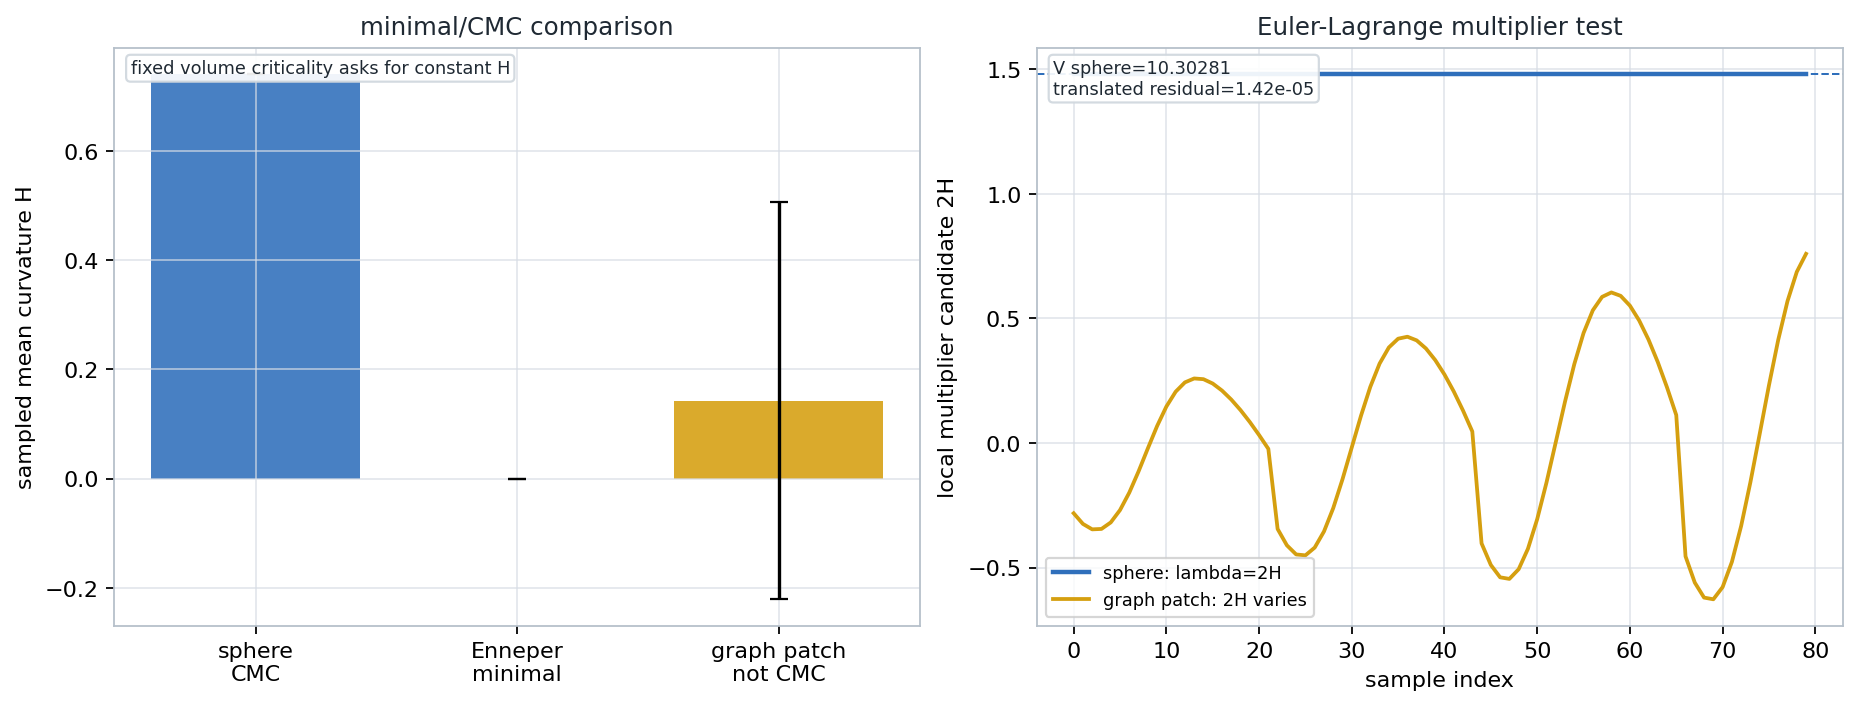

In [8]:
def sphere_grid(radius: float, lat_count: int = 151, lon_count: int = 181, shift: np.ndarray | None = None) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    lon = np.linspace(0.0, 2.0 * np.pi, lon_count)
    lat = np.linspace(-0.5 * np.pi, 0.5 * np.pi, lat_count)
    Lon, Lat = np.meshgrid(lon, lat)
    F_sphere = np.stack([
        radius * np.cos(Lat) * np.cos(Lon),
        radius * np.cos(Lat) * np.sin(Lon),
        radius * np.sin(Lat),
    ], axis=-1)
    if shift is not None:
        F_sphere = F_sphere + shift
    return lon, lat, F_sphere


def cone_volume(surface: np.ndarray, lon: np.ndarray, lat: np.ndarray) -> float:
    dF_dlat, dF_dlon = np.gradient(surface, lat, lon, axis=(0, 1), edge_order=2)
    integrand = np.einsum("ijk,ijk->ij", surface, np.cross(dF_dlon, dF_dlat)) / 3.0
    return trapz2(integrand, lon, lat)


radius = 1.35
lon, lat, sphere = sphere_grid(radius)
translated = sphere + np.array([0.7, -0.25, 0.4])
cone_base = cone_volume(sphere, lon, lat)
cone_translated = cone_volume(translated, lon, lat)
cone_exact = 4.0 * math.pi * radius**3 / 3.0

sphere_H_samples = np.full(200, 1.0 / radius)
minimal_H_samples = np.zeros(200)
graph_H_samples = data["H"][10:-10:6, 10:-10:6].ravel()
models = ["sphere\nCMC", "Enneper\nminimal", "graph patch\nnot CMC"]
means = [float(np.mean(sphere_H_samples)), float(np.mean(minimal_H_samples)), float(np.mean(graph_H_samples))]
stds = [float(np.std(sphere_H_samples)), float(np.std(minimal_H_samples)), float(np.std(graph_H_samples))]

mean_volume_checks = {
    **symbolic_checks,
    "sphere_cone_volume_numeric": float(cone_base),
    "sphere_cone_volume_exact": float(cone_exact),
    "sphere_cone_volume_abs_error": float(abs(cone_base - cone_exact)),
    "translated_sphere_cone_volume_numeric": float(cone_translated),
    "cone_volume_translation_abs_error": float(abs(cone_translated - cone_base)),
    "sphere_H_std": stds[0],
    "minimal_model_H_std": stds[1],
    "graph_patch_H_std": stds[2],
    "sphere_area_volume_multiplier_numeric": float(2.0 / radius),
}
assert mean_volume_checks["sphere_cone_volume_abs_error"] < 5e-3
assert mean_volume_checks["cone_volume_translation_abs_error"] < 2e-3
assert mean_volume_checks["sphere_H_std"] < 1e-14
assert mean_volume_checks["minimal_model_H_std"] < 1e-14
assert mean_volume_checks["graph_patch_H_std"] > 1e-2

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), constrained_layout=True)
axes[0].bar(models, means, yerr=stds, color=[PALETTE["blue"], PALETTE["green"], PALETTE["gold"]], alpha=0.88, capsize=4)
axes[0].set_ylabel("sampled mean curvature H")
add_note(axes[0], "fixed volume criticality asks for constant H")
style_axis(axes[0], "minimal/CMC comparison")

lambda_values = [2 * value for value in sphere_H_samples[:80]]
graph_lambda = 2 * graph_H_samples[: min(80, graph_H_samples.size)]
axes[1].plot(lambda_values, color=PALETTE["blue"], lw=2.0, label="sphere: lambda=2H")
axes[1].plot(graph_lambda, color=PALETTE["gold"], lw=1.7, label="graph patch: 2H varies")
axes[1].axhline(2.0 / radius, color=PALETTE["blue"], lw=0.9, ls="--")
axes[1].set_xlabel("sample index")
axes[1].set_ylabel("local multiplier candidate 2H")
axes[1].legend(fontsize=8)
add_note(axes[1], f"V sphere={cone_base:.5f}\ntranslated residual={abs(cone_translated-cone_base):.2e}")
style_axis(axes[1], "Euler-Lagrange multiplier test")

cmc_path = save_matplotlib(fig, TOPIC, "figures", "mean-curvature-volume-constraint.png")
plt.close(fig)
cmc_checks_path = save_json(mean_volume_checks, TOPIC, "checks", "mean-curvature-volume-checks.json")
display_artifact(cmc_path)
display_artifact(cmc_checks_path)


## Applied Lab: What to Perturb

The safest experiment is to modify the normal speed `phi` or the tangential field `Z` above and rerun the area-variation cell. Three outcomes should remain stable.

First, if `phi` vanishes near the boundary, the normal finite difference should continue to match `2∫phi H det`. Second, if `Z` is changed while the surface is held fixed, the tangential finite difference should follow the boundary flux rather than the interior picture alone. Third, if the graph height is changed to make `H` nearly constant, the right panel in the CMC comparison should flatten toward a constant multiplier.


In [9]:
artifact_paths = [
    ARTIFACT_ROOT / TOPIC / "figures" / "surface-vector-calculus-dashboard.png",
    ARTIFACT_ROOT / TOPIC / "figures" / "variation-field-decomposition.png",
    ARTIFACT_ROOT / TOPIC / "figures" / "first-area-variation-diagnostics.png",
    ARTIFACT_ROOT / TOPIC / "figures" / "mean-curvature-volume-constraint.png",
    ARTIFACT_ROOT / TOPIC / "interactive" / "normal-variation-area-lab.html",
    ARTIFACT_ROOT / TOPIC / "checks" / "visual-storyboard.json",
    ARTIFACT_ROOT / TOPIC / "checks" / "surface-vector-calculus-checks.json",
    ARTIFACT_ROOT / TOPIC / "checks" / "variation-decomposition-checks.json",
    ARTIFACT_ROOT / TOPIC / "checks" / "area-variation-checks.json",
    ARTIFACT_ROOT / TOPIC / "checks" / "normal-variation-area-samples.json",
    ARTIFACT_ROOT / TOPIC / "checks" / "mean-curvature-volume-checks.json",
]

final_sanity = {
    "source_span": {"printed_pages": CHAPTER["printed_pages"], "pdf_pages": CHAPTER["pdf_pages"]},
    "core_identity_residuals": {
        "div_J_grad_max_abs_interior": vector_checks["div_J_grad_max_abs_interior"],
        "product_rule_max_abs_interior": vector_checks["product_rule_max_abs_interior"],
        "divergence_theorem_abs_error": vector_checks["divergence_theorem_abs_error"],
        "variation_reconstruction_max_abs_error": variation_checks["reconstruction_max_abs_error"],
        "normal_area_abs_error": area_checks["normal_area_abs_error"],
        "tangential_area_abs_error": area_checks["tangential_area_abs_error"],
        "cone_volume_translation_abs_error": mean_volume_checks["cone_volume_translation_abs_error"],
    },
    "artifacts": {},
}

for path in artifact_paths:
    assert path.exists(), path
    min_bytes = 1000 if path.suffix.lower() != ".json" else 40
    assert path.stat().st_size > min_bytes, path
    rel = book_relative(path)
    final_sanity["artifacts"][rel] = {"bytes": int(path.stat().st_size)}
    if path.suffix.lower() == ".png":
        stats = image_stats(path)
        assert stats["width"] >= 500 and stats["height"] >= 300, path
        assert stats["pixel_std"] > 1.0, path
        final_sanity["artifacts"][rel].update({"width": stats["width"], "height": stats["height"], "pixel_std": stats["pixel_std"]})

assert final_sanity["core_identity_residuals"]["normal_area_abs_error"] < 5e-5
assert final_sanity["core_identity_residuals"]["tangential_area_abs_error"] < 5e-5
assert final_sanity["core_identity_residuals"]["cone_volume_translation_abs_error"] < 2e-3

final_sanity_path = save_json(final_sanity, TOPIC, "checks", "final-sanity.json")
display_artifact(final_sanity_path)


## Takeaways

A variation field has two geometrically different jobs: `phi N` changes the surface shape, while `df(Z)` changes the parametrization and contributes to area through the boundary. Mean curvature is the normal gradient of area in the source convention: positive `H` on the outward sphere means outward normal motion increases area. Minimal surfaces are the unconstrained critical points of area, and adding the fixed cone-volume constraint replaces `H=0` with the Euler-Lagrange condition that `H` is constant.
